#### AI 헬스케어 첫번째 미니 프로젝트 “흡연 여부 데이터 분석을 통한 건강 인사이트 도출” 에 오신 여러분 환영합니다.
이번 프로젝트에서는 흡연여부를 판단하는 데이터를 가지고 시각화 및 가설을 판별해보려고 합니다.


A-Z로 진행되는 만큼 천천히 따라해보세요!

#### 팀 과제
- 데이터 구조, 분포 확인, 전처리 : 1.1_흡연여부데이터
- 데이터 간 관계 가설 수립 및 검증 : 1.2_데이터분석



### 흡연여부데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와
흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며,
통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

	•	흡연자와 비흡연자 간의 건강 지표 차이 분석
	•	주요 변수들의 분포, 상관관계, 통계적 유의성 검증
	•	시각화를 통한 데이터 인사이트 도출
	•	추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련


In [1]:
# 필요한 라이브러리들 불러오기

# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석 라이브러리
from scipy import stats


In [2]:
import platform
import matplotlib.pyplot as plt

KOREAN_FONT = 'AppleGothic' if platform.system() == 'Darwin' else 'AppleGothic'
plt.rc('font', family=KOREAN_FONT)
plt.rcParams['axes.unicode_minus'] = False

In [3]:
import matplotlib.pyplot as plt
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] =False



---



In [4]:
#CSV 파일 불러오기
health_data = pd.read_csv("../data/smoking_health_data.csv")

### 1. 가설 수립 (인당 최소 3개)

건강 지표별로 흡연자/비흡연자 간 통계적 차이 검증

(예시)
- H₀ (귀무가설): BMI- 흡연자와 비흡연자의 평균 BMI는 같다.
- H₁ (대립가설): BMI- 흡연자와 비흡연자의 평균 BMI는 다르다.

In [5]:
### 아래에 3가지의 가설을 설정해보세요.
# 가설 1. 흡연 여부에 따라 BMI와 헤모글로빈 수치는 유의미한 차이를 보일 것이다.
# 가설 2. 흡연 여부에 따라 동맥경화 지수(AI)는 유의미한 차이를 보일 것이다.
# 가설 3. 흡연자 집단 내에서 충치 유무에 따라 대사 지표(공복혈당, 간 효소)의 차이가 존재할 것이다.

## 2. 단변량 분석

	단변량 분석 의미 찾기:

    •	데이터 품질(결측, 이상치) 확인

    •	모델 입력값 기준 설정

- 숫자형, 범주형
- 전처리 사항
  - NaN 존재 여부 및 조치 방안
  - 가변수화 대상여부
- 기초통계량 확인
- 분포 확인
- 위 정보로부터 파악한 비즈니스 내용 정리
- 추가 분석해볼 사항 도출

In [6]:
#데이터 확인
print('==== 데이터 확인 =====')
health_data.head()

==== 데이터 확인 =====


,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0


In [7]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 기본 정보 확인 및 클렌징
print("===== 데이터 기본 정보 =====")
print(health_data.info())
print("\n===== 결측치 확인 =====")
print(health_data.isnull().sum())

===== 데이터 기본 정보 =====
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   str    
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        6860 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     6860 non-null   float64
 8   혈압        6860 non-null   float64
 9   중성 지방     6860 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
dtypes: float64(8), int64(9), str(1)
memory usage: 1.0 MB
None

===== 결측치 확인 =====
ID            0
나이 

In [8]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 숫자형, 범주형 변수 분리
numeric_cols = health_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = health_data.select_dtypes(include=['object', 'category']).columns

print("\n===== 숫자형 변수 =====")
print(numeric_cols)
print("\n===== 범주형 변수 =====")
print(categorical_cols)


===== 숫자형 변수 =====
Index(['나이', '키(cm)', '몸무게(kg)', 'BMI', '시력', '충치', '공복 혈당', '혈압', '중성 지방',
       '혈청 크레아티닌', '콜레스테롤', '고밀도지단백', '저밀도지단백', '헤모글로빈', '요 단백', '간 효소율',
       'label'],
      dtype='str')

===== 범주형 변수 =====
Index(['ID'], dtype='str')


/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/1286043840.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = health_data.select_dtypes(include=['object', 'category']).columns


In [9]:
#BMI를 기준으로 체중 상태 구분 칼럼
bins = [0, 18.5, 25, 30, 50]
labels = ["저체중", "정상", "과체중", "비만"]
health_data["체중 상태"] = pd.cut(health_data["BMI"], bins=bins, labels=labels, right=True)

#나이'를 기준으로 나이대를 구분하는 칼럼
bins = [0, 30, 49, 69, 100]
labels = ["청년(-30)", "중년(31-49)", "장년(50-69)", "노년(70-)"]
health_data["나이대"] = pd.cut(health_data["나이"], bins=bins, labels=labels, right=True)

health_data.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,체중 상태,나이대
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,정상,중년(31-49)
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,정상,중년(31-49)
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중,장년(50-69)
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상,중년(31-49)
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,과체중,장년(50-69)


In [10]:
# 데이터 전처리

# 1 혈압(중앙값으로 대체)
bp_midian = health_data['혈압'].median()
health_data['혈압'] = health_data['혈압'].fillna(bp_midian)

# 2 시력(최빈값으로 대체)
vision_mode = health_data['시력'].mode()[0]
health_data['시력'] = health_data['시력'].fillna(vision_mode)

# 3 나이대별 중성지방(그룹 평균 대체)
health_data['중성 지방'] = health_data['중성 지방'].fillna(
    health_data.groupby('나이대', observed=True)['중성 지방'].transform('mean'))

# 4 공복 혈당(평균으로 채우기)
fbs_mean = health_data['공복 혈당'].mean()
health_data['공복 혈당'] = health_data['공복 혈당'].fillna(fbs_mean)

print("\n===== 결측치 재확인 =====")
print(health_data.isnull().sum())


===== 결측치 재확인 =====
ID          0
나이          0
키(cm)       0
몸무게(kg)     0
BMI         0
시력          0
충치          0
공복 혈당       0
혈압          0
중성 지방       0
혈청 크레아티닌    0
콜레스테롤       0
고밀도지단백      0
저밀도지단백      0
헤모글로빈       0
요 단백        0
간 효소율       0
label       0
체중 상태       0
나이대         0
dtype: int64


In [11]:
# 1. 수치형 데이터 전체의 기초통계량 확인
print(health_data.describe())

                나이        키(cm)      몸무게(kg)          BMI           시력  \
count  7000.000000  7000.000000  7000.000000  7000.000000  7000.000000   
mean     43.973571   164.781429    65.932857    24.144423     1.015186   
std      12.063793     9.170213    12.978702     3.501945     0.426631   
min      20.000000   135.000000    30.000000    14.270000     0.100000   
25%      35.000000   160.000000    55.000000    21.600000     0.800000   
50%      40.000000   165.000000    65.000000    23.880000     1.000000   
75%      50.000000   170.000000    75.000000    26.120000     1.200000   
max      85.000000   190.000000   130.000000    42.450000     9.900000   

                충치        공복 혈당           혈압        중성 지방     혈청 크레아티닌  \
count  7000.000000  7000.000000  7000.000000  7000.000000  7000.000000   
mean      0.227429    99.307289    45.544000   127.025826     0.884900   
std       0.419202    20.977056     8.743135    72.484759     0.241523   
min       0.000000    57.000000    14

In [12]:
### 단변량 분석에서 파악한 내용을 정리해보세요.
#BMI 이상치 제거
# Q1(25%), Q3(75%) 계산
Q1 = health_data['BMI'].quantile(0.25)
Q3 = health_data['BMI'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 경계 설정
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거 후 새로운 데이터프레임 생성
health_filtered = health_data[(health_data['BMI'] >= lower_bound) & (health_data['BMI'] <= upper_bound)]

print(f"제거 전 데이터 개수: {len(health_data)}")
print(f"제거 후 데이터 개수: {len(health_filtered)}")
print(f"정상 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")

제거 전 데이터 개수: 7000
제거 후 데이터 개수: 6878
정상 범위: 14.82 ~ 32.90


In [13]:
#헤모글로빈 이상치 제거
# Q1(25%), Q3(75%) 계산
Q1 = health_data['헤모글로빈'].quantile(0.25)
Q3 = health_data['헤모글로빈'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 경계 설정
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거 후 새로운 데이터프레임 생성
health_filtered = health_data[
    (health_data['헤모글로빈'] >= lower_bound) & (health_data['헤모글로빈'] <= upper_bound)
]

print(f"제거 전 데이터 개수: {len(health_data)}")
print(f"제거 후 데이터 개수: {len(health_filtered)}")
print(f"정상 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")

제거 전 데이터 개수: 7000
제거 후 데이터 개수: 6913
정상 범위: 10.45 ~ 18.85


📍전반적인 건강 지표 비교

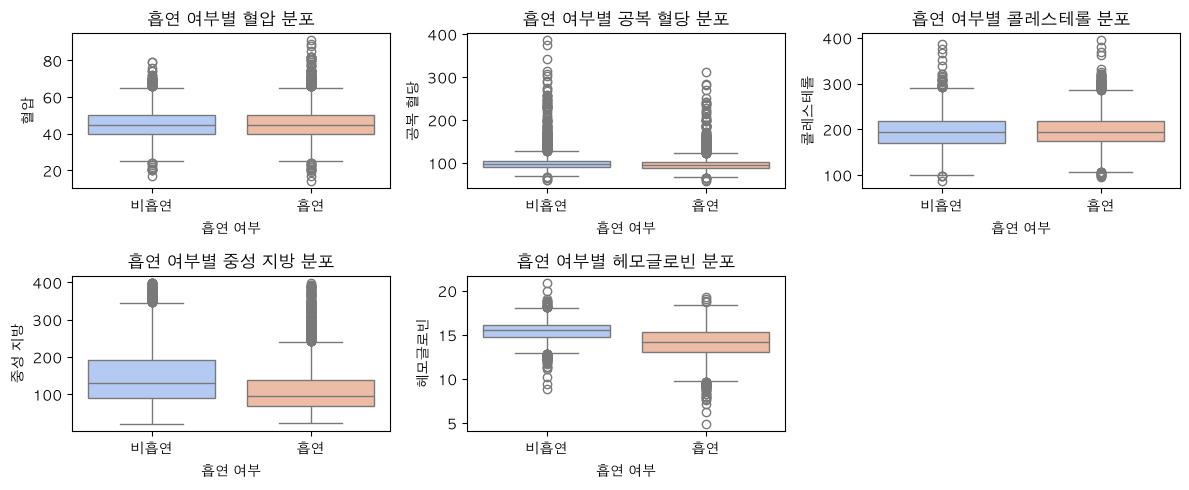

In [14]:
plt.figure(figsize=(12, 5))

health_data["흡연 여부"] = health_data['label'].replace({0: "비흡연", 1:  "흡연"})

#1. 첫 번째 차트: 흡연 여부별 혈압 분포
plt.subplot(2,3,1)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="혈압",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 혈압 분포")
plt.xlabel('흡연 여부')
plt.ylabel('혈압')
plt.xticks([0, 1], ['비흡연', '흡연'])

#2. 두 번째 차트: 흡연 여부별 공복 혈당 분포
plt.subplot(2,3,2)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="공복 혈당",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 공복 혈당 분포")
plt.xlabel('흡연 여부')
plt.ylabel('공복 혈당')
plt.xticks([0, 1], ['비흡연', '흡연'])

#3. 세 번째 차트: 흡연 여부별 콜레스테롤 분포
plt.subplot(2,3,3)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="콜레스테롤",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 콜레스테롤 분포")
plt.xlabel('흡연 여부')
plt.ylabel('콜레스테롤')
plt.xticks([0, 1], ['비흡연', '흡연'])


#4. 네 번째 차트: 흡연 여부별 중성 지방 분포
plt.subplot(2,3,4)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="중성 지방",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 중성 지방 분포")
plt.xlabel('흡연 여부')
plt.ylabel('중성 지방')
plt.xticks([0, 1], ['비흡연', '흡연'])

#5. 다섯 번째 차트: 흡연 여부별 헤모글로빈 분포
plt.subplot(2,3,5)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="헤모글로빈",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 헤모글로빈 분포")
plt.xlabel('흡연 여부')
plt.ylabel('헤모글로빈')
plt.xticks([0, 1], ['비흡연', '흡연'])

plt.tight_layout()
plt.savefig('../images/02_hypothesis/01_건강지표_비교.png', dpi=150, bbox_inches='tight')
plt.show()


**혈압, 공복 혈당**, 콜레스테롤 세 지표 모두 박스의 위치(중앙값)는 비흡연자와 흡연자 사이에 큰 차이가 없어 보임. **상단 이상치(Outliers)**를 보면 흡연자 그룹에서 혈압과 혈당이 비정상적으로 높은 사람들이 더 밀집되어 나타나는 경향이 있음

**중성 지방** 데이터상으로는 오히려 비흡연자 그룹의 중위값이 조금 더 높아 보이는데, 이는 데이터셋의 연령대나 식습관 변수가 섞여 있을 가능성이 크다. 다만, 흡연자 그룹의 상단 꼬리가 매우 길어 고중성지방혈증 위험군이 존재함을 보여줍니다.

**헤모글로빈** 비흡연자보다 흡연자 그룹의 헤모글로빈 수치 중앙값이 낮게 형성되어 있습니다. 보통 흡연은 수치를 높인다고 알려져 있는데, 이 데이터에서는 오히려 흡연군에서 빈혈 기여도가 높거나 영양 불균형이 있을 가능성을 시사함.

흡연 여부에 따른 주요 건강 지표

/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/53287986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='BMI', data=health_data, ax=axes[0], palette='Set2', showfliers=True)
/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/53287986.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['비흡연자(0)', '흡연자(1)'])
/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/53287986.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='몸무게(kg)', data=health_data, ax=axes[1], palette='Past

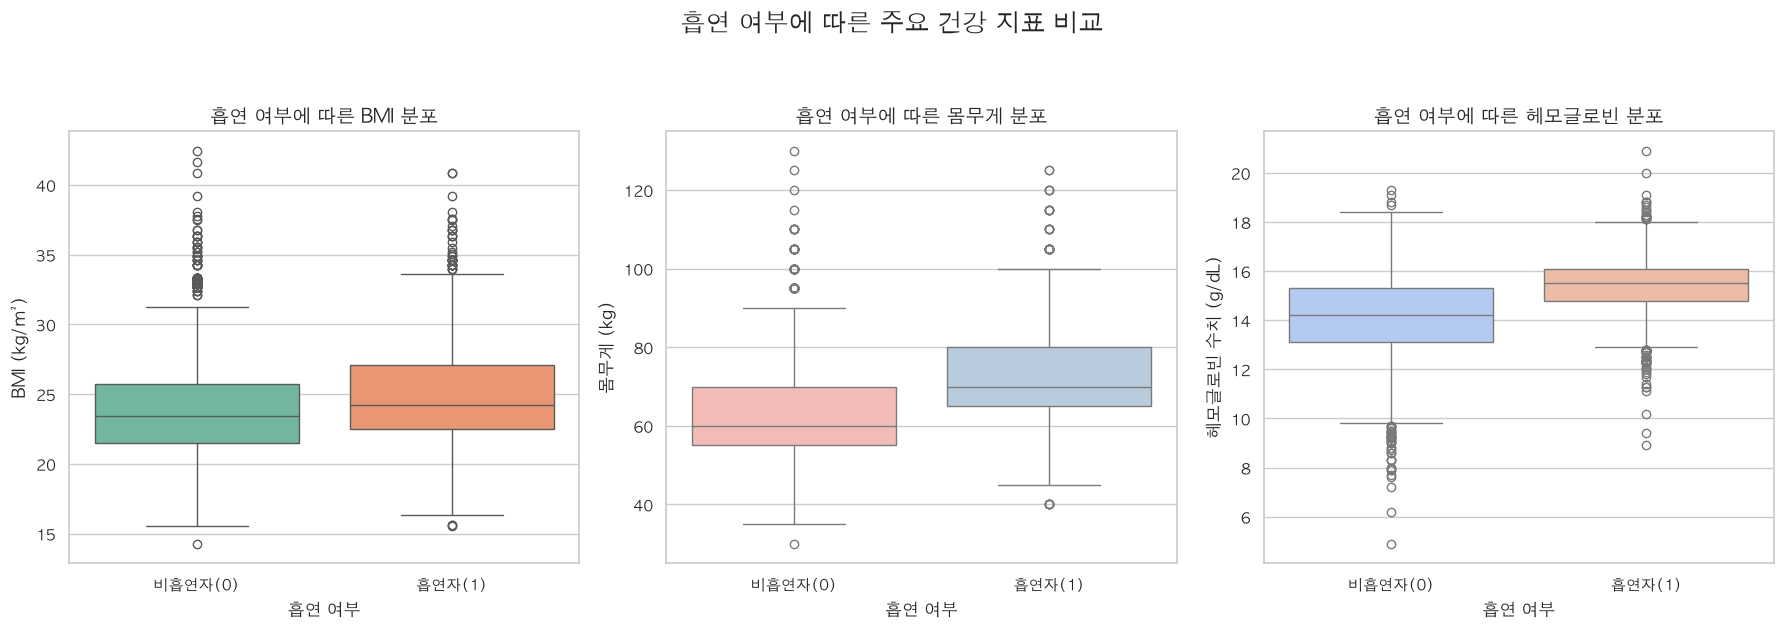

In [15]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='AppleGothic')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- ① BMI 비교 ---
sns.boxplot(x='label', y='BMI', data=health_data, ax=axes[0], palette='Set2', showfliers=True)
axes[0].set_title('흡연 여부에 따른 BMI 분포', fontsize=14)
axes[0].set_xlabel('흡연 여부')
axes[0].set_ylabel('BMI (kg/m²)')
axes[0].set_xticklabels(['비흡연자(0)', '흡연자(1)'])

# --- ② 몸무게 비교 ---
sns.boxplot(x='label', y='몸무게(kg)', data=health_data, ax=axes[1], palette='Pastel1', showfliers=True)
axes[1].set_title('흡연 여부에 따른 몸무게 분포', fontsize=14)
axes[1].set_xlabel('흡연 여부')
axes[1].set_ylabel('몸무게 (kg)')
axes[1].set_xticklabels(['비흡연자(0)', '흡연자(1)'])

# --- ③ 헤모글로빈 비교 ---
sns.boxplot(x='label', y='헤모글로빈', data=health_data, ax=axes[2], palette='coolwarm', showfliers=True)
axes[2].set_title('흡연 여부에 따른 헤모글로빈 분포', fontsize=14)
axes[2].set_xlabel('흡연 여부')
axes[2].set_ylabel('헤모글로빈 수치 (g/dL)')
axes[2].set_xticklabels(['비흡연자(0)', '흡연자(1)'])

plt.suptitle('흡연 여부에 따른 주요 건강 지표 비교', fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig('../images/02_hypothesis/02_BMI_몸무게_헤모글로빈.png', dpi=150, bbox_inches='tight')
plt.show()

나이대별 BMI 분포

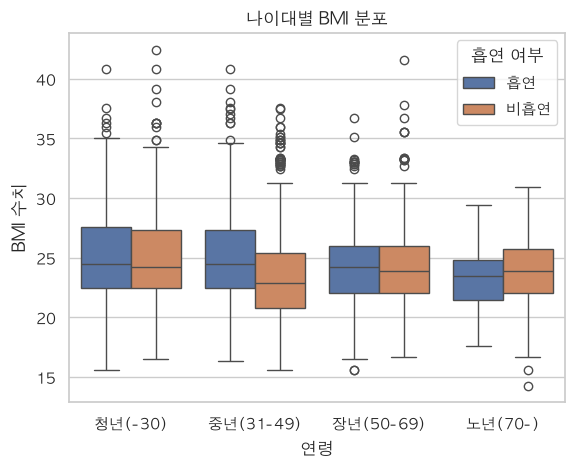

In [16]:
# 나이대별 BMI분포
health_data["흡연 여부"] = health_data['label'].replace({0: "비흡연", 1:  "흡연"})

sns.boxplot(data=health_data, x="나이대",
             y='BMI',
             hue="흡연 여부",
             palette="deep")


plt.title('나이대별 BMI 분포')
plt.xlabel('연령')
plt.ylabel('BMI 수치')

plt.savefig('../images/02_hypothesis/03_나이대별_BMI_분포.png', dpi=150, bbox_inches='tight')
plt.show()

흡연 여부에 따른 BMI 분포

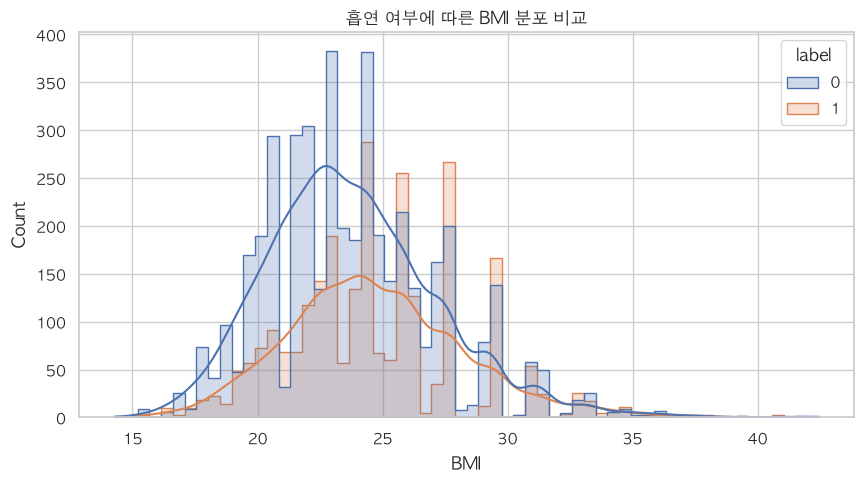

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] =False

# BMI 수치의 분포 확인
plt.figure(figsize=(10, 5))
sns.histplot(data=health_data, x='BMI', kde=True, hue='label', element="step")
plt.title('흡연 여부에 따른 BMI 분포 비교')
plt.savefig('../images/02_hypothesis/04_BMI_분포_비교.png', dpi=150, bbox_inches='tight')
plt.show()

흡연 여부에 따른 BMI 분포를 비교한 결과,
흡연자는 비흡연자에 비해 BMI 분포의 중심이 다소 높은 경향을 보였다.
특히 과체중 및 비만 구간(BMI ≥ 25)에서 흡연자의 분포 비중이 상대적으로 크게 나타났다.
이는 흡연 여부가 체중 및 체질량지수와 일정 수준의 관련성을 가질 가능성을 시사한다.

In [18]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# 1. 데이터 추출
bmi_smoker = health_data[health_data['label'] == 1]['BMI']
bmi_nonsmoker = health_data[health_data['label'] == 0]['BMI']

# 2. 정규성 검정 (Shapiro-Wilk)
stat_s, p_s = shapiro(bmi_smoker)
stat_n, p_n = shapiro(bmi_nonsmoker)

print(f"📊 [정규성 검정] 흡연자 p-value: {p_s:.5e} / 비흡연자 p-value: {p_n:.5e}")

# 3. 통계 검정 실시
# 두 그룹 중 하나라도 p-value < 0.05이면 정규성이 깨진 것으로 간주 -> 비모수 검정
if p_s < 0.05 or p_n < 0.05:
    test_name = "Mann-Whitney U Test (비모수 검정)"
    u_stat, p_val = mannwhitneyu(bmi_smoker, bmi_nonsmoker, alternative='two-sided')
else:
    test_name = "Independent T-test (모수 검정)"
    t_stat, p_val = ttest_ind(bmi_smoker, bmi_nonsmoker, equal_var=False)

# 4. 결과 출력
print("-" * 65)
print(f"🧪 사용된 검정법: {test_name}")
print(f"▶ 흡연자 BMI 평균   : {bmi_smoker.mean():.2f}")
print(f"▶ 비흡연자 BMI 평균 : {bmi_nonsmoker.mean():.2f}")
print(f"▶ 유의확률 (P-value): {p_val:.5e}")
print("-" * 65)

if p_val < 0.05:
    print(f"📢 [결론] 흡연 여부에 따른 BMI 차이는 '통계적으로 유의미'합니다.")
    diff = bmi_smoker.mean() - bmi_nonsmoker.mean()
    word = "높음" if diff > 0 else "낮음"
    print(f"   (흡연자의 BMI가 비흡연자보다 평균적으로 {abs(diff):.2f}만큼 {word})")
else:
    print(f"📢 [결론] 흡연 여부에 따른 BMI 차이는 '통계적으로 유의미하지 않습니다'.")

📊 [정규성 검정] 흡연자 p-value: 1.65573e-18 / 비흡연자 p-value: 5.04822e-27
-----------------------------------------------------------------
🧪 사용된 검정법: Mann-Whitney U Test (비모수 검정)
▶ 흡연자 BMI 평균   : 24.73
▶ 비흡연자 BMI 평균 : 23.81
▶ 유의확률 (P-value): 1.58843e-28
-----------------------------------------------------------------
📢 [결론] 흡연 여부에 따른 BMI 차이는 '통계적으로 유의미'합니다.
   (흡연자의 BMI가 비흡연자보다 평균적으로 0.92만큼 높음)


나이대 별 흡연 여부에 따른 헤모글로빈 수치 분포

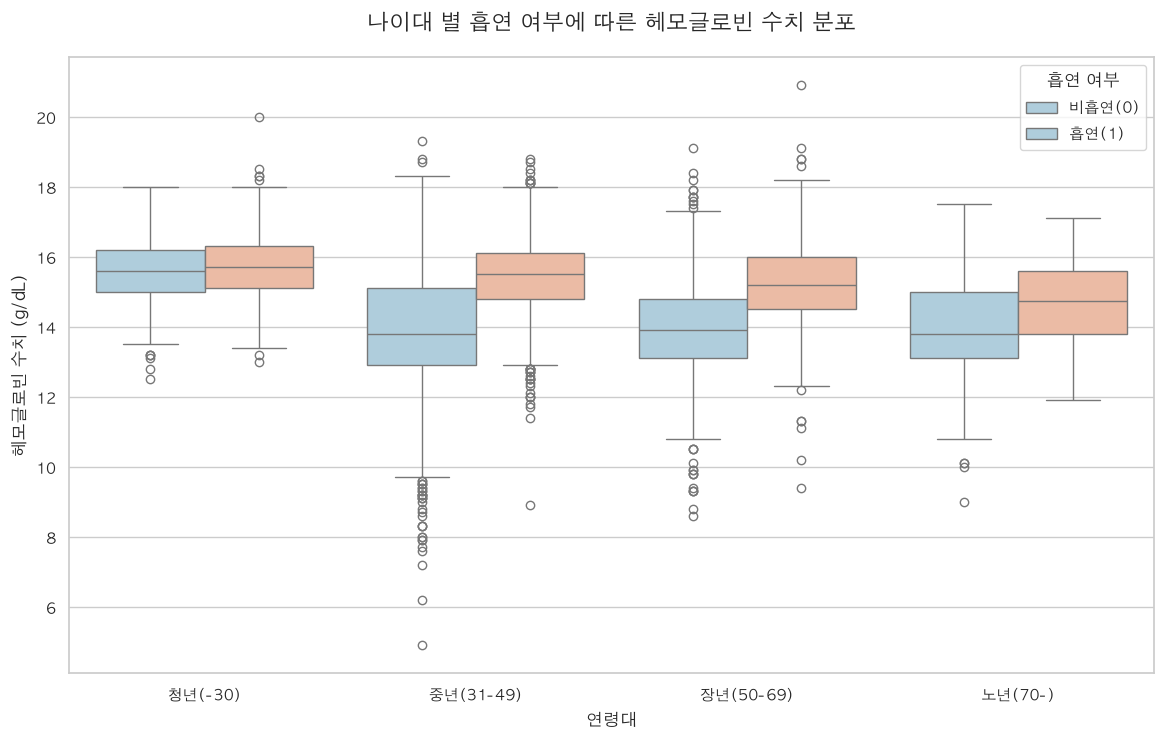


[ 나이대별/흡연여부별 헤모글로빈 평균 수치 ]
label              0          1
나이대                            
청년(-30)    15.560703  15.725222
중년(31-49)  13.891122  15.450898
장년(50-69)  13.979244  15.224608
노년(70-)    13.933333  14.700000


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 설정 및 스타일 적용
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='AppleGothic')

# 2. 그래프 그리기
plt.figure(figsize=(14, 8))

# x축은 나이대 순서대로, hue는 흡연여부(label)로 설정
sns.boxplot(data=health_data,
            x='나이대',
            y='헤모글로빈',
            hue='label',
            palette='RdBu_r',  # 비흡연(0)은 푸른색, 흡연(1)은 붉은색 계열
            showfliers=True)   # 이상치 표시 (점들이 너무 많으면 False로 변경)

# 3. 그래프 꾸미기
plt.title('나이대 별 흡연 여부에 따른 헤모글로빈 수치 분포', fontsize=16, pad=20)
plt.xlabel('연령대', fontsize=12)
plt.ylabel('헤모글로빈 수치 (g/dL)', fontsize=12)
plt.legend(title='흡연 여부', labels=['비흡연(0)', '흡연(1)'])

# 4. 평균 수치 확인을 위한 통계 요약표 (선택 사항)
plt.savefig('../images/02_hypothesis/05_나이대별_헤모글로빈.png', dpi=150, bbox_inches='tight')
plt.show()

# 실제 수치 차이 확인
age_smoking_summary = health_data.groupby(['나이대', 'label'])['헤모글로빈'].mean().unstack()
print("\n[ 나이대별/흡연여부별 헤모글로빈 평균 수치 ]")
print(age_smoking_summary)

흡연여부에 따른 헤모글로빈 수치 비교

/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/2291470231.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=health_data, x='label', y='헤모글로빈', palette='RdBu_r', ax=axes[0])
/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/2291470231.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['비흡연자', '흡연자'])


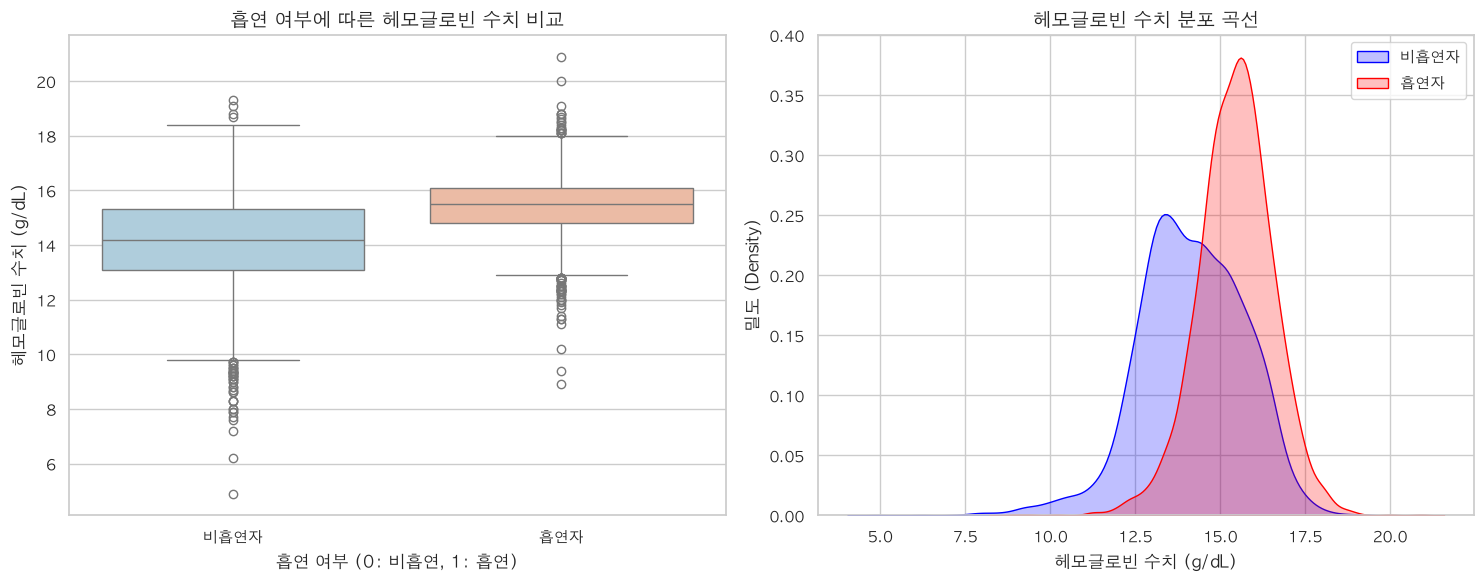


[ 헤모글로빈 수치 요약 ]
            mean  median       std
label                             
0      14.159991    14.2  1.557501
1      15.444885    15.5  1.114335


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 및 스타일 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='AppleGothic')

# 2. 도화지 준비 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- [그래프 1] 박스 플롯 (Box Plot) ---
sns.boxplot(data=health_data, x='label', y='헤모글로빈', palette='RdBu_r', ax=axes[0])
axes[0].set_title('흡연 여부에 따른 헤모글로빈 수치 비교', fontsize=14)
axes[0].set_xlabel('흡연 여부 (0: 비흡연, 1: 흡연)')
axes[0].set_ylabel('헤모글로빈 수치 (g/dL)')
axes[0].set_xticklabels(['비흡연자', '흡연자'])

# --- [그래프 2] 밀도 그래프 (KDE Plot) ---
sns.kdeplot(data=health_data[health_data['label'] == 0]['헤모글로빈'],
            fill=True, label='비흡연자', ax=axes[1], color='blue')
sns.kdeplot(data=health_data[health_data['label'] == 1]['헤모글로빈'],
            fill=True, label='흡연자', ax=axes[1], color='red')
axes[1].set_title('헤모글로빈 수치 분포 곡선', fontsize=14)
axes[1].set_xlabel('헤모글로빈 수치 (g/dL)')
axes[1].set_ylabel('밀도 (Density)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/02_hypothesis/06_헤모글로빈_비교.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. 평균값 출력으로 확인
print("\n[ 헤모글로빈 수치 요약 ]")
print(health_data.groupby('label')['헤모글로빈'].agg(['mean', 'median', 'std']))

흡연 여부에 따른 헤모글로빈 수치를 비교한 결과,
흡연자 집단에서 비흡연자보다 헤모글로빈 중앙값이 높게 나타났다.
분포 곡선 분석에서도 흡연자의 헤모글로빈 분포가
전반적으로 높은 방향으로 이동한 것을 확인할 수 있었다.
이는 흡연으로 인한 만성 저산소 상태에 대한
생리적 보상 반응으로 헤모글로빈 수치가 증가했을 가능성을 시사한다.

In [21]:
#통계 검정
from scipy.stats import ttest_ind

smoker_hemo = health_data[health_data['label'] == 1]['헤모글로빈']
nonsmoker_hemo = health_data[health_data['label'] == 0]['헤모글로빈']

# 독립표본 T-검정 수행 (등분산성 가정 X: Welchs T-test 적용)
t_stat, p_val = ttest_ind(smoker_hemo, nonsmoker_hemo, equal_var=False)

# 평균값 계산 (결과 해석용)
mean_smoker = smoker_hemo.mean()
mean_nonsmoker = nonsmoker_hemo.mean()

# 결과 출력
print("="*60)
print(f"{'헤모글로빈 수치 차이 분석 결과':^50}")
print("="*60)
print(f"▶ 흡연자 평균 : {mean_smoker:.2f} g/dL")
print(f"▶ 비흡연자 평균: {mean_nonsmoker:.2f} g/dL")
print(f"▶ T-통계량    : {t_stat:.4f}")
print(f"▶ 유의확률(P) : {p_val:.5e}")
print("-" * 60)

if p_val < 0.05:
    print(f"✅ 결과: 유의확률이 {p_val:.5f}로 0.05보다 작으므로,")
    print("   흡연 여부에 따른 헤모글로빈 수치 차이는 [통계적으로 매우 유의미]합니다.")
    if mean_smoker > mean_nonsmoker:
        print(f"   👉 흡연군이 비흡연군보다 약 {mean_smoker - mean_nonsmoker:.2f} g/dL 더 높습니다.")
else:
    print(f"❌ 결과: 유의확률이 {p_val:.5f}로 0.05보다 크므로,")
    print("   흡연 여부에 따른 헤모글로빈 수치 차이는 [통계적으로 유의미하지 않습니다].")
print("="*60)

                헤모글로빈 수치 차이 분석 결과                 
▶ 흡연자 평균 : 15.44 g/dL
▶ 비흡연자 평균: 14.16 g/dL
▶ T-통계량    : 40.0224
▶ 유의확률(P) : 0.00000e+00
------------------------------------------------------------
✅ 결과: 유의확률이 0.00000로 0.05보다 작으므로,
   흡연 여부에 따른 헤모글로빈 수치 차이는 [통계적으로 매우 유의미]합니다.
   👉 흡연군이 비흡연군보다 약 1.28 g/dL 더 높습니다.


### 단변량 분석에서 파악한 내용을 정리해보세요.
헤모글로빈 수치: 흡연 여부에 따른 차이가 매우 유의미하며, 흡연이 신체 혈액 생리학적 지표를 직접적으로 변화시킨다는 것이 입증되었다
BMI: 통계적 유의성은 확보될 수 있으나, 헤모글로빈만큼 뚜렷한 임상적 차이를 보이지는 않는다

BMI 및 일부 대사 지표는 차이가 존재하였으나, 흡연 단독 요인보다는 개인의 생활습관 및 체질적 요인의 영향을 함께 받는 것으로 판단된다.
반면,흡연자는 비흡연자에 비해 헤모글로빈 수치가 유의미하게 높게 나타났다.
이는 흡연으로 인한 만성적인 산소 부족 상태를 보상하기 위해 체내 산소 운반 능력이 증가한 결과로 해석할 수 있다.

✅흡연 여부에 따른 생리적 차이는 명확히 존재하며,
헤모글로빈은 흡연 여부를 가장 잘 설명하는 대표적인 생리 지표로 확인되었다.


## 3.이변량 분석
	이변량 분석 의미 찾기:

    •	변수 간 원인–결과 관계 탐색

    •	어떤 요인이 가장 큰 영향을 주는지 도출

    •	향후 예측 모델 설계 시 주요 Feature 후보 선별

- 가설검정시 다음의 항목을 참조하여 수행합니다.
  - 유의수준 : 5%
  - 숫자 --> 숫자 : 상관분석
  - 범주 --> 범주 : 카이제곱검정
  - 범주 --> 숫자 : t검정, 분산분석
  - 숫자 --> 범주 : 로지스틱 회귀모형을 통해, 회귀계수의 P.value로 검정을 수행합니다.

In [22]:
# CSV 파일 재로딩
health_data = pd.read_csv("../data/smoking_health_data.csv")

# 파생 변수 생성
health_data["체중 상태"] = pd.cut(health_data["BMI"],
    bins=[0, 18.5, 25, 30, 50], labels=["저체중", "정상", "과체중", "비만"], right=True)
health_data["나이대"] = pd.cut(health_data["나이"],
    bins=[0, 30, 49, 69, 100], labels=["청년(-30)", "중년(31-49)", "장년(50-69)", "노년(70-)"], right=True)

# 결측치 처리
health_data['혈압'] = health_data['혈압'].fillna(health_data['혈압'].median())
health_data['시력'] = health_data['시력'].fillna(health_data['시력'].mode()[0])
health_data['중성 지방'] = health_data['중성 지방'].fillna(
    health_data.groupby('나이대', observed=True)['중성 지방'].transform('mean'))
health_data['공복 혈당'] = health_data['공복 혈당'].fillna(health_data['공복 혈당'].mean())

# 흡연 여부 컬럼
health_data["흡연 여부"] = health_data['label'].replace({0: "비흡연", 1: "흡연"})

In [23]:
# 필요한 라이브러리들 불러오기

# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석 라이브러리
from scipy import stats

# 가설 2. 흡연 여부에 따라 동맥경화 지수(AI)는 유의미한 차이를 보일 것이다.

동맥경화 지수(AI)란

동맥경화 지수(Atherogenic Index, AI)는 지질 대사 위험을 종합적으로 나타내는 지표로,다음과 같이 정의된다.
AI = (총 콜레스테롤 - 고밀도지단백 콜레스테롤) / 고밀도지단백 콜레스테롤

In [24]:
# 동맥경화 지수(AI) 계산

health_data['AI'] = (
(health_data['콜레스테롤'] - health_data['고밀도지단백'])
/ health_data['고밀도지단백']
)

health_data[['콜레스테롤', '고밀도지단백', 'AI']].head()

,콜레스테롤,고밀도지단백,AI
0,211,75,1.813333
1,251,46,4.456522
2,144,43,2.348837
3,178,66,1.696970
4,232,62,2.741935


In [25]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.

In [26]:
# 동맥경화 지수(AI)수치의 단변량 통계표
print('===== 동맥경화 지수(AI)수치의 단변량 통계표 =====')
print(health_data['AI'].describe())

# 흡연 여부에 따른 AI 평균 비교
print('\n=====흡연 여부에 따른 AI 평균 비교=====')
health_data.groupby('label')['AI'].mean()

===== 동맥경화 지수(AI)수치의 단변량 통계표 =====
count    7000.000000
mean        2.627078
std         1.034507
min         0.300000
25%         1.862947
50%         2.482451
75%         3.236253
max         8.897436
Name: AI, dtype: float64

=====흡연 여부에 따른 AI 평균 비교=====


label
0    2.498147
1    2.849183
Name: AI, dtype: float64

흡연 여부에 따른 AI 분포를 그래프

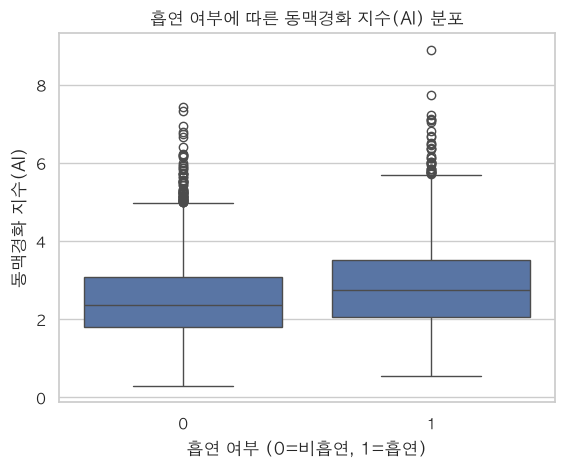

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=health_data,
    x='label',
    y='AI'
)

plt.title('흡연 여부에 따른 동맥경화 지수(AI) 분포')
plt.xlabel('흡연 여부 (0=비흡연, 1=흡연)')
plt.ylabel('동맥경화 지수(AI)')
plt.savefig('../images/02_hypothesis/07_동맥경화지수_분포.png', dpi=150, bbox_inches='tight')
plt.show()


흡연 여부에 따른 '저밀도지단백(LDL)과 총 콜레스테롤 상관관계 비교

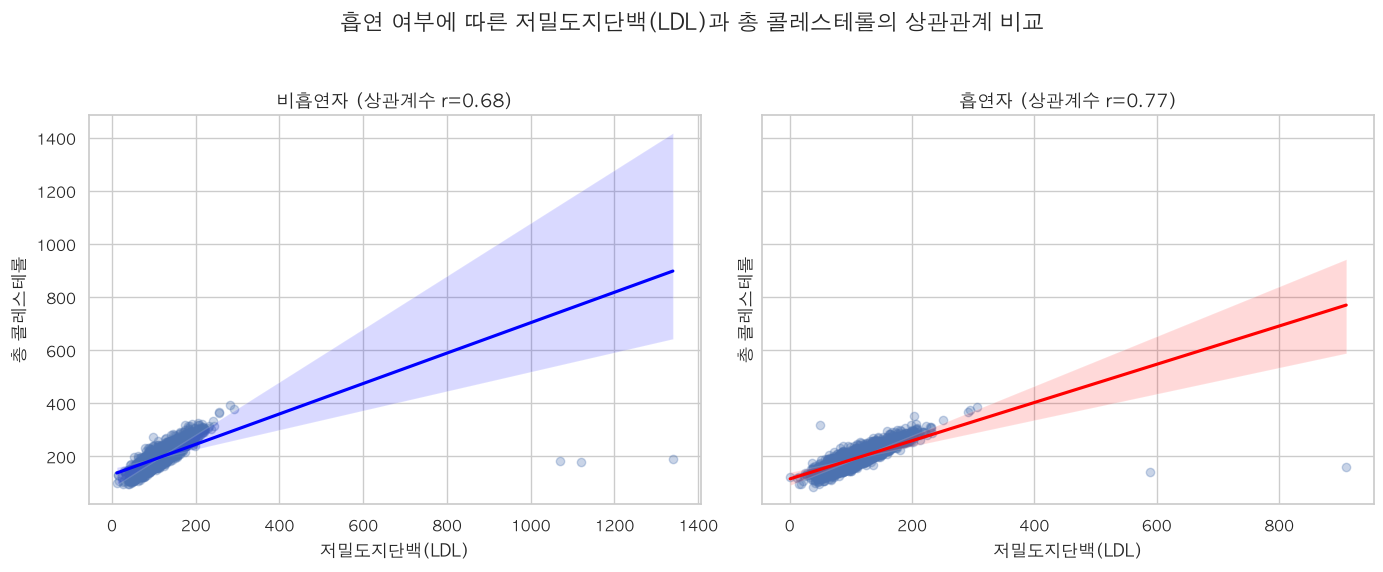

--------------------------------------------------
▶ 비흡연자 상관계수: 0.684
▶ 흡연자 상관계수: 0.775
▶ 두 그룹 간 상관계수 차이의 P-value: 0.00000
--------------------------------------------------
결론: 흡연 여부에 따라 LDL과 콜레스테롤의 관계가 통계적으로 유의미하게 다릅니다.


In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, norm

# 1. 한글 및 스타일 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set(style="whitegrid", font='AppleGothic')

# 2. 데이터 분류
df_non = health_data[health_data['label'] == 0]    # 비흡연자
df_smoke = health_data[health_data['label'] == 1]  # 흡연자

# 3. 상관계수(r)와 유의확률(p) 계산
corr_non, p_non = pearsonr(df_non['저밀도지단백'], df_non['콜레스테롤'])
corr_smoke, p_smoke = pearsonr(df_smoke['저밀도지단백'], df_smoke['콜레스테롤'])

# 4. 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# [왼쪽: 비흡연자]
sns.regplot(x='저밀도지단백', y='콜레스테롤', data=df_non, ax=axes[0],
            scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
axes[0].set_title(f'비흡연자 (상관계수 r={corr_non:.2f})', fontsize=13)
axes[0].set_xlabel('저밀도지단백(LDL)')
axes[0].set_ylabel('총 콜레스테롤')

# [오른쪽: 흡연자]
sns.regplot(x='저밀도지단백', y='콜레스테롤', data=df_smoke, ax=axes[1],
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1].set_title(f'흡연자 (상관계수 r={corr_smoke:.2f})', fontsize=13)
axes[1].set_xlabel('저밀도지단백(LDL)')
axes[1].set_ylabel('총 콜레스테롤')

plt.suptitle('흡연 여부에 따른 저밀도지단백(LDL)과 총 콜레스테롤의 상관관계 비교', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../images/02_hypothesis/08_LDL_콜레스테롤_상관관계.png', dpi=150, bbox_inches='tight')
plt.show()

#흡연자와 비흡연자 사이의 LDL-콜레스테롤 상관관계 차이를 검정
# 5. 상관계수 차이 검정 (Fisher Z-test) 함수
def fisher_z_test(r1, r2, n1, n2):
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    se = np.sqrt(1/(n1-3) + 1/(n2-3))
    z = (z1 - z2) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return z, p

z_stat, p_diff = fisher_z_test(corr_non, corr_smoke, len(df_non), len(df_smoke))

# 결과 출력
print("-" * 50)
print(f"▶ 비흡연자 상관계수: {corr_non:.3f}")
print(f"▶ 흡연자 상관계수: {corr_smoke:.3f}")
print(f"▶ 두 그룹 간 상관계수 차이의 P-value: {p_diff:.5f}")
print("-" * 50)

if p_diff < 0.05:
    print("결론: 흡연 여부에 따라 LDL과 콜레스테롤의 관계가 통계적으로 유의미하게 다릅니다.")
else:
    print("결론: 두 그룹 간 상관관계의 차이가 통계적으로 유의미하지 않습니다.")

In [29]:
# 동맥경화 지수(AI) 분석 (Mann-Whitney U Test)
# 정규성을 따르지 않는 데이터에 대해 비모수 검정을 수행하고 기술 통계량을 확인

from scipy.stats import shapiro, mannwhitneyu

# 1. 그룹 분리
non_smoker_ai = health_data.loc[health_data['label'] == 0, 'AI'].dropna()
smoker_ai = health_data.loc[health_data['label'] == 1, 'AI'].dropna()

# 2. 정규성 검정 (Shapiro-Wilk)
stat_n, p_n = shapiro(non_smoker_ai)
stat_s, p_s = shapiro(smoker_ai)

print("\n[ AI 지수 정규성 검정 ]")
print(f"▶ 비흡연자 정규성 P-value: {p_n:.5e}")
print(f"▶ 흡연자 정규성 P-value: {p_s:.5e}")
print("※ 해석: P-value < 0.05이므로 정규성을 따르지 않음 -> 비모수 검정(Mann-Whitney) 채택")

# 3. Mann-Whitney U Test 실행
u_stat, p_val_mw = mannwhitneyu(non_smoker_ai, smoker_ai, alternative='two-sided')

print("\n[AI 지수 집단 간 차이 검정 (비모수) ]")
print(f"▶ Mann-Whitney U 통계량: {u_stat:.1f}")
print(f"▶ 유의확률 (P-value): {p_val_mw:.5e}")

if p_val_mw < 0.05:
    print("결과: 흡연군과 비흡연군의 동맥경화 지수(AI)는 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결과: 두 집단 간 동맥경화 지수(AI) 차이가 유의미하지 않습니다.")

# 4. 기술 통계량 요약
ai_summary = health_data.groupby('label')['AI'].agg(['mean', 'median', 'std'])
ai_summary.index = ['비흡연군(0)', '흡연군(1)']
print("\n[ AI 지수 기술 통계량 ]")
print(ai_summary)


[ AI 지수 정규성 검정 ]
▶ 비흡연자 정규성 P-value: 7.23888e-32
▶ 흡연자 정규성 P-value: 8.91114e-21
※ 해석: P-value < 0.05이므로 정규성을 따르지 않음 -> 비모수 검정(Mann-Whitney) 채택

[AI 지수 집단 간 차이 검정 (비모수) ]
▶ Mann-Whitney U 통계량: 4614485.5
▶ 유의확률 (P-value): 5.28672e-40
결과: 흡연군과 비흡연군의 동맥경화 지수(AI)는 통계적으로 유의미한 차이가 있습니다.

[ AI 지수 기술 통계량 ]
             mean    median       std
비흡연군(0)  2.498147  2.360656  0.964696
흡연군(1)   2.849183  2.755556  1.110445


# 가설 3. 흡연자 집단 내에서 충치 유무에 따라 대사 지표(공복혈당, 간 효소)의 차이가 존재할 것이다.

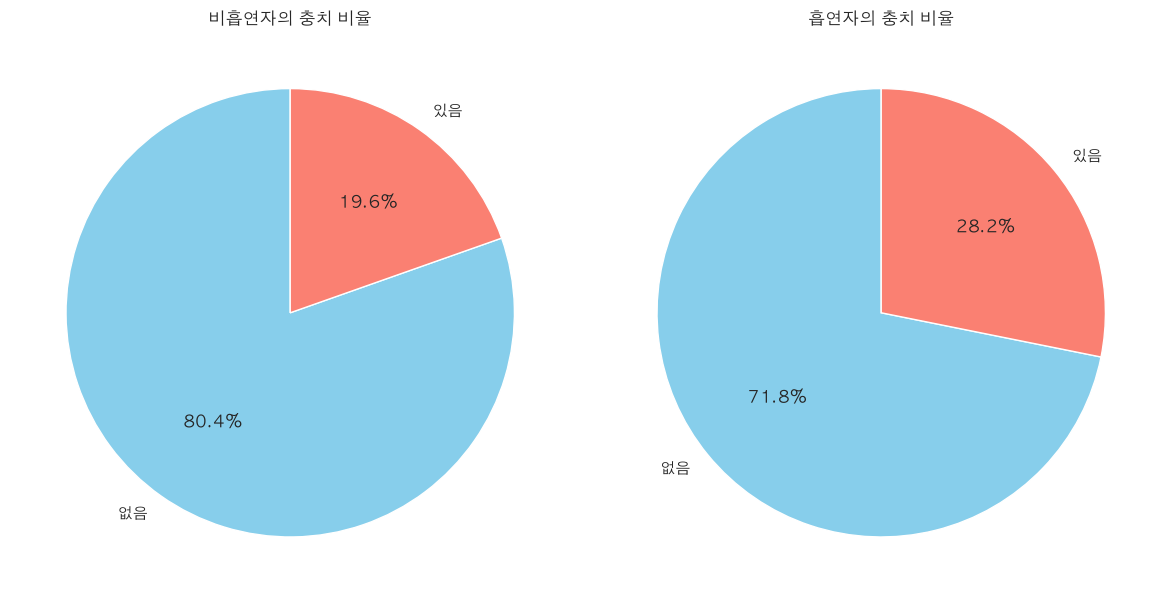

In [30]:
# 흡연 여부에 따른 충치 환자 분포
# 1.흡연 여부로 나누기
smoke_0 = health_data[health_data['흡연 여부'] == '비흡연']['충치'].value_counts()
smoke_1 = health_data[health_data['흡연 여부'] == '흡연']['충치'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# 왼쪽: 비흡연자 파이 차트
ax[0].pie(smoke_0, labels=['없음', '있음'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
ax[0].set_title('비흡연자의 충치 비율')

# 오른쪽: 흡연자 파이 차트
ax[1].pie(smoke_1, labels=['없음', '있음'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
ax[1].set_title('흡연자의 충치 비율')

plt.tight_layout()
plt.savefig('../images/02_hypothesis/09_충치_비율.png', dpi=150, bbox_inches='tight')
plt.show()

# 흡연 여부에 따른 충치 환자의 혈당 및 간 효소율 수치

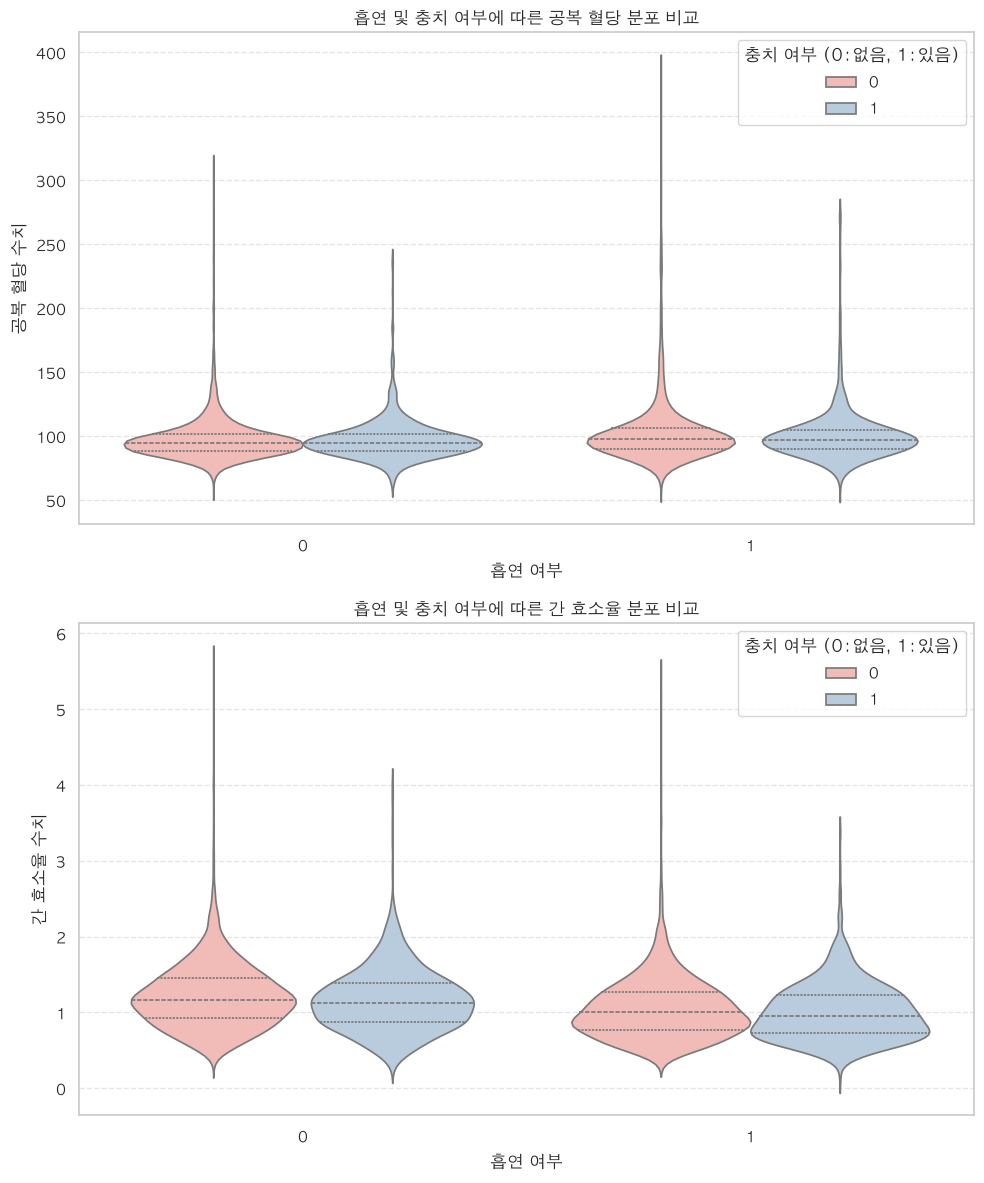

In [31]:

plt.figure(figsize=(10, 12))
# 흡연 여부에 따른 충치 환자의 혈당 수치
plt.subplot(2,1,1)
sns.violinplot(data=health_data, x='label', y='공복 혈당',
               hue='충치', palette='Pastel1', inner="quartile")

plt.title('흡연 및 충치 여부에 따른 공복 혈당 분포 비교')
plt.xlabel('흡연 여부')
plt.ylabel('공복 혈당 수치')
plt.legend(title='충치 여부 (0:없음, 1:있음)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 흡연 여부에 따른 충치 환자의 간 효소율 수치
plt.subplot(2,1,2)
sns.violinplot(data=health_data, x='label', y='간 효소율',
               hue='충치', palette='Pastel1', inner="quartile")

plt.title('흡연 및 충치 여부에 따른 간 효소율 분포 비교')
plt.xlabel('흡연 여부')
plt.ylabel('간 효소율 수치')
plt.legend(title='충치 여부 (0:없음, 1:있음)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../images/02_hypothesis/10_충치_대사지표_violinplot.png', dpi=150, bbox_inches='tight')
plt.show()

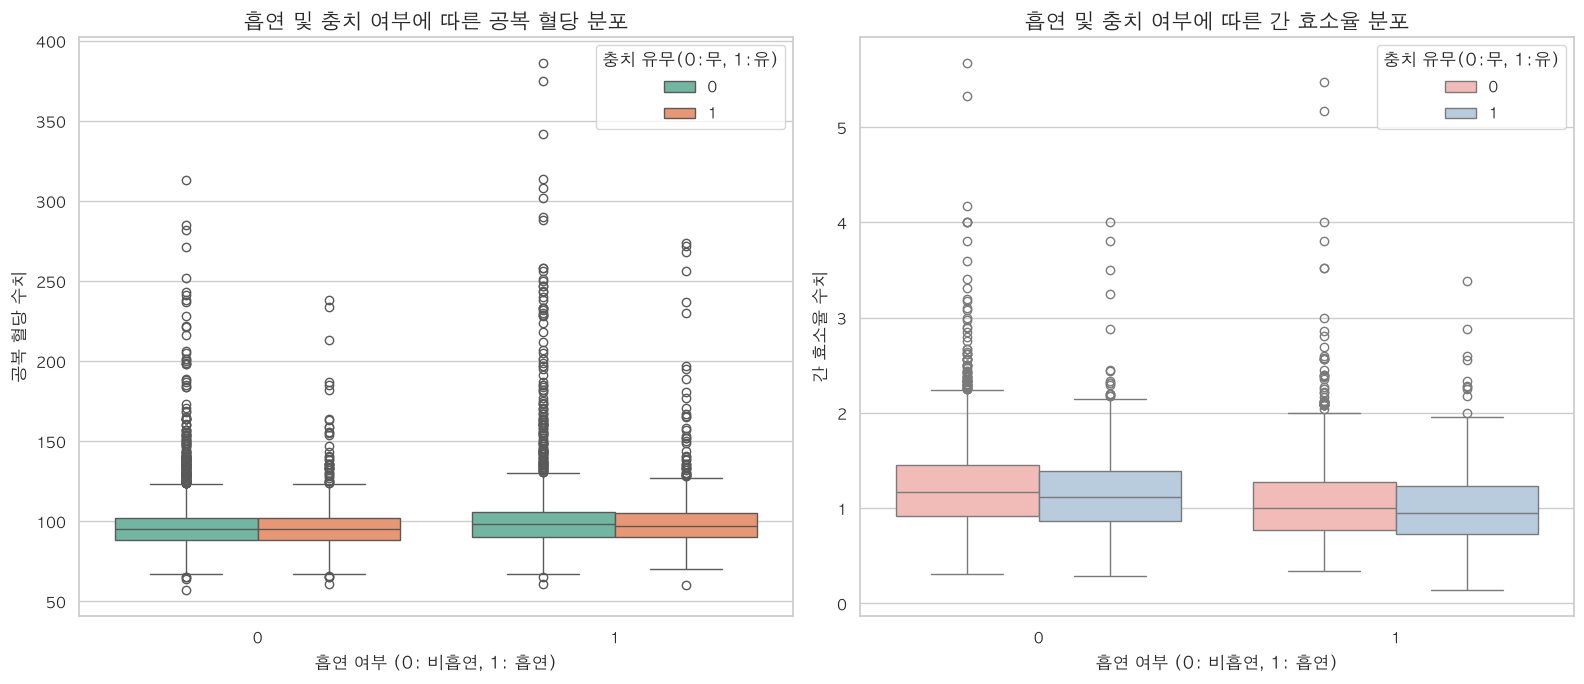

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 스타일 설정
sns.set_theme(style="whitegrid", font='AppleGothic')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- [그래프 1] 흡연 및 충치 여부별 공복 혈당 ---
sns.boxplot(data=health_data, x='label', y='공복 혈당', hue='충치',
            palette='Set2', ax=axes[0])
axes[0].set_title('흡연 및 충치 여부에 따른 공복 혈당 분포', fontsize=15)
axes[0].set_xlabel('흡연 여부 (0: 비흡연, 1: 흡연)', fontsize=12)
axes[0].set_ylabel('공복 혈당 수치', fontsize=12)
axes[0].legend(title='충치 유무(0:무, 1:유)')

# --- [그래프 2] 흡연 및 충치 여부별 간 효소율 ---
sns.boxplot(data=health_data, x='label', y='간 효소율', hue='충치',
            palette='Pastel1', ax=axes[1])
axes[1].set_title('흡연 및 충치 여부에 따른 간 효소율 분포', fontsize=15)
axes[1].set_xlabel('흡연 여부 (0: 비흡연, 1: 흡연)', fontsize=12)
axes[1].set_ylabel('간 효소율 수치', fontsize=12)
axes[1].legend(title='충치 유무(0:무, 1:유)')

plt.tight_layout()
plt.savefig('../images/02_hypothesis/11_충치_대사지표_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**'흡연자 집단 내'**에서 충치유무에 따른 간 효소율 및 혈당 차이 그래프

충치
0    1847
1     724
Name: count, dtype: int64
  variable  mean_no_caries  mean_caries    t_stat   p_value  n_no_caries  \
0    공복 혈당      103.075097   100.730226  2.241515  0.025126         1811   
1    간 효소율        1.053194     1.007486  2.654312  0.008033         1847   

   n_caries  
0       708  
1       724  
  variable    U_stat   p_value
0    공복 혈당  653294.0  0.457050
1    간 효소율  709922.0  0.014681


/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/2840434144.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='충치', y=var, data=df_smoker, palette='Set2')


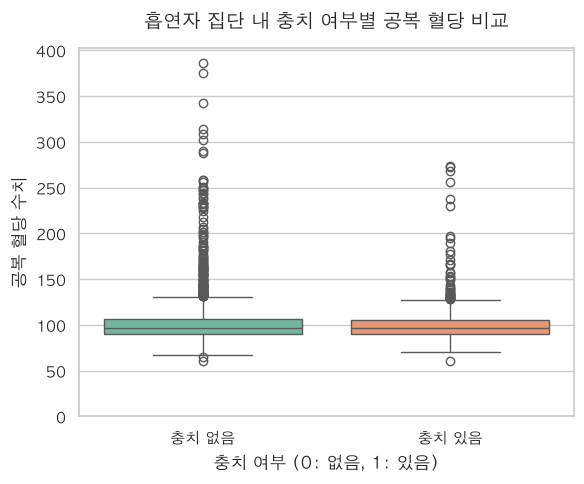

/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/2840434144.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='충치', y=var, data=df_smoker, palette='Set2')


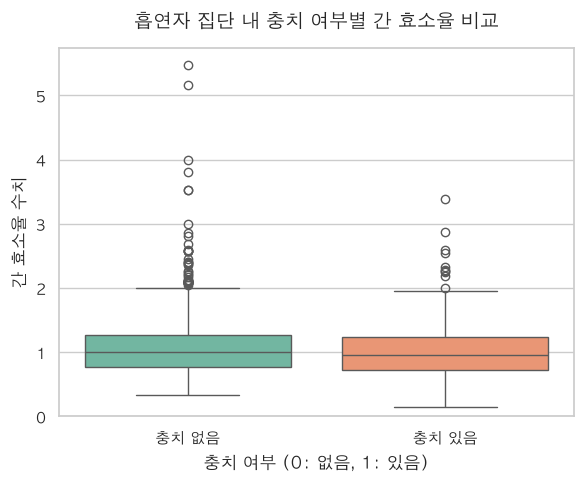

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu

sns.set(style="whitegrid")
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("../data/smoking_health_data.csv")  # 파일명 맞게 수정
# 흡연자만 필터링
df_smoker = df[df['label'] == 1]

print(df_smoker['충치'].value_counts())
metabolic_vars = [
    '공복 혈당', # '공복혈당'을 '공복 혈당'으로 수정
    '간 효소율',   # 'AST', 'ALT' 대신 '간 효소율'로 수정
]
results = []

for var in metabolic_vars:
    group_no = df_smoker[df_smoker['충치'] == 0][var].dropna()
    group_yes = df_smoker[df_smoker['충치'] == 1][var].dropna()

    t_stat, p_val = ttest_ind(group_no, group_yes, equal_var=False)

    results.append({
        'variable': var,
        'mean_no_caries': group_no.mean(),
        'mean_caries': group_yes.mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'n_no_caries': len(group_no),
        'n_caries': len(group_yes)
    })

ttest_results = pd.DataFrame(results)
print(ttest_results)
mw_results = []

for var in metabolic_vars:
    group_no = df_smoker[df_smoker['충치'] == 0][var].dropna()
    group_yes = df_smoker[df_smoker['충치'] == 1][var].dropna()

    u_stat, p_val = mannwhitneyu(group_no, group_yes, alternative='two-sided')

    mw_results.append({
        'variable': var,
        'U_stat': u_stat,
        'p_value': p_val
    })

mw_results = pd.DataFrame(mw_results)
print(mw_results)
for var in metabolic_vars:
    plt.figure(figsize=(6, 5)) # 크기를 살짝 조절하여 글자가 잘 안 겹치게 함

    # 박스 플롯 그리기
    sns.boxplot(x='충치', y=var, data=df_smoker, palette='Set2')

    # 그래프 제목 설정 (변수명에 따라 자동으로 바뀜)
    plt.title(f'흡연자 집단 내 충치 여부별 {var} 비교', fontsize=14, pad=15)

    # X축 이름 설정
    plt.xlabel('충치 여부 (0: 없음, 1: 있음)', fontsize=12)

    # Y축 이름 설정 (데이터 컬럼명인 '공복 혈당', '간 효소율'이 들어감)
    plt.ylabel(f'{var} 수치', fontsize=12)

    # X축 눈금 이름 한글로 직접 지정 (0 -> 없음, 1 -> 있음)
    plt.xticks([0, 1], ['충치 없음', '충치 있음'])

    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(f'../images/02_hypothesis/12_흡연자_충치별_{var.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [34]:
from scipy import stats

print("=== 가설 3: 통계적 유의성 검증 결과 ===\n")

# 1. [흡연 여부 vs 충치] - 카이제곱 검정 (범주형 vs 범주형)
# 흡연이 충치 발생 빈도에 영향을 주는지 확인
cross_tab = pd.crosstab(health_data['흡연 여부'], health_data['충치'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(cross_tab)
print(f"1. 흡연 여부와 충치 발생의 상관관계 (카이제곱 검정)")
print(f"   - P-value: {p_chi2:.4f}")
print(f"   - 결과: {'유의함' if p_chi2 < 0.05 else '유의하지 않음'}\n")

# 2. [충치 여부 vs 공복 혈당] - 독립표본 T-검정 (범주형 vs 수치형)
# 충치(염증)가 있는 사람의 혈당이 통계적으로 더 높은지 확인
group_no_cavity = health_data[health_data['충치'] == 0]['공복 혈당']
group_cavity = health_data[health_data['충치'] == 1]['공복 혈당']
t_stat_sugar, p_val_sugar = stats.ttest_ind(group_no_cavity, group_cavity)
print(f"2. 충치 유무에 따른 공복 혈당 차이 (T-검정)")
print(f"   - P-value: {p_val_sugar:.4f}")
print(f"   - 결과: {'유의함' if p_val_sugar < 0.05 else '유의하지 않음'}\n")

# 3. [충치 여부 vs 간 효소율] - 독립표본 T-검정 (범주형 vs 수치형)
# 충치(염증)가 있는 사람의 간 수치가 통계적으로 더 높은지 확인
group_no_cavity_liver = health_data[health_data['충치'] == 0]['간 효소율']
group_cavity_liver = health_data[health_data['충치'] == 1]['간 효소율']
t_stat_liver, p_val_liver = stats.ttest_ind(group_no_cavity_liver, group_cavity_liver)
print(f"3. 충치 유무에 따른 간 효소율 차이 (T-검정)")
print(f"   - P-value: {p_val_liver:.4f}")
print(f"   - 결과: {'유의함' if p_val_liver < 0.05 else '유의하지 않음'}")

=== 가설 3: 통계적 유의성 검증 결과 ===

1. 흡연 여부와 충치 발생의 상관관계 (카이제곱 검정)
   - P-value: 0.0000
   - 결과: 유의함

2. 충치 유무에 따른 공복 혈당 차이 (T-검정)
   - P-value: 0.3694
   - 결과: 유의하지 않음

3. 충치 유무에 따른 간 효소율 차이 (T-검정)
   - P-value: 0.0000
   - 결과: 유의함


### 이변량 분석에서 파악한 내용을 정리해보세요.
흡연자는 비흡연자에 비해 동맥경화 지수(AI)가 높게 나타났으며, 해당 차이는 통계적으로 유의미하였다.
이는 흡연이 HDL 감소 및 LDL 산화를 촉진하여 지질 대사 불균형을 유발하고, 심혈관계 질환 위험을 증가시킨다는 기존 연구 결과와 일치한다.
또한 흡연자 집단에서 LDL과 총콜레스테롤 간 상관구조가 비흡연자와 다르게 나타나 흡연이 지질 대사 패턴 자체에 영향을 미치는 것으로 해석된다.

✅흡연은 동맥경화 지수를 통해 심혈관 질환 위험과 밀접한 관련성을 가지며,
흡연 여부는 심혈관계 건강 위험을 평가하는 주요 요인으로 작용한다.

✅흡연은 충치 발생과 유의한 관련성을 가지며,충치는 간 효소율과 같은 일부 대사 관련 지표와 연관성을 보였다.
그러나 공복 혈당과의 관계는 통계적으로 유의하지 않아,충치가 혈당 상승 요인이라고 결론짓기에는 근거가 부족하다.


In [35]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.

추가적으로 각 건강 지표 간의 관계도 이해해봅시다!
예를 들어, BMI, 혈압, 혈당, 콜레스테롤 등의 수치형 변수들은 서로 영향을 주고받을 수 있으며, 이를 통해 건강 상태를 종합적으로 이해하거나, 향후 모델 설계 및 연구 방향을 제안할 수 있습니다.
추가적인 인사이트를 얻어볼까요 ?

### 상관계수를 구하고 HeatMap으로 시각화 후 분석을 해보세요.
- Heatmap: 변수 간의 상관관계(Correlation)를 색상으로 쉽게 확인할 수 있는 시각화 방법입니다.
- 해석 기준:
  - 값이 1에 가까울수록 → 강한 양의 상관관계
  - 값이 -1에 가까울수록 → 강한 음의 상관관계
  - 값이 0에 가까울수록 → 관계가 약함

이를 통해 변수 간 관계를 한눈에 비교하고, 분석에 필요한 주요 변수를 파악할 수 있습니다.

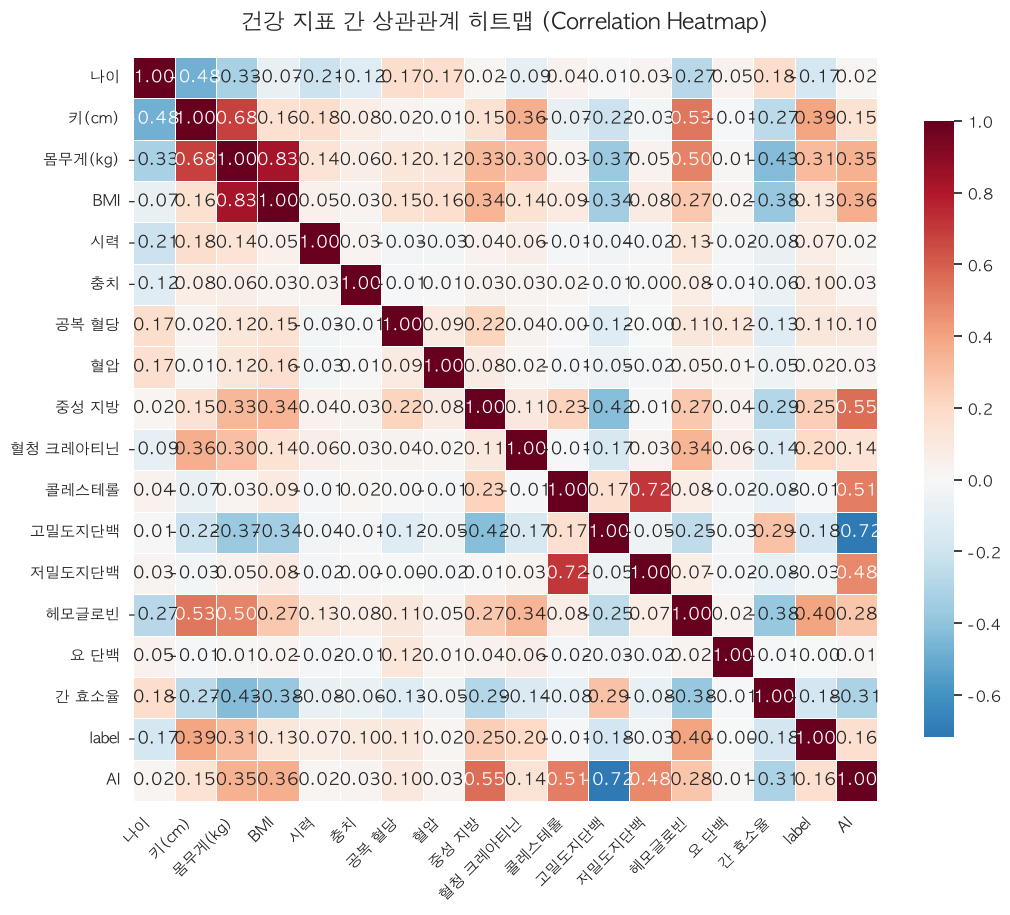

In [36]:
# 아래에 실습코드를 작성하고 상관계수를 확인 및 시각화 합니다.

import numpy as np
plt.rc('font', family='AppleGothic')

# 2. 상관계수 계산 (수치형 데이터만)
numeric_cols = health_data.select_dtypes(include=['number']).columns
corr = health_data[numeric_cols].corr()

# 4. 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8},
            square=True)

plt.title('건강 지표 간 상관관계 히트맵 (Correlation Heatmap)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.savefig('../images/02_hypothesis/13_상관관계_히트맵.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 관계 정리
- 강한 관계의 변수
- 약한 관계의 변수

In [37]:
# 1. 상관관계 계산 (전체 변수 대상)

# label(흡연여부) 컬럼과의 상관계수만 추출
smoking_corr = corr['label'].drop('label')

# 2. 상관관계가 강한 TOP 5 (절대값 기준 내림차순)
strong_corr = smoking_corr.abs().sort_values(ascending=False).head(5)

# 3. 상관관계가 약한 TOP 5 (절대값 기준 오름차순)
weak_corr = smoking_corr.abs().sort_values(ascending=True).head(5)

print("\n🔥 [분석 1] 흡연과 상관관계가 '강한' 변수 TOP 5")
print("이 변수들은 흡연 여부에 따라 수치가 크게 변할 가능성이 높습니다.")
print("-" * 50)
for i, (var, corr_val) in enumerate(strong_corr.items(), 1):
    # 원래 상관계수 값을 보여주기 위해 smoking_corr에서 다시 가져옴
    actual_corr = smoking_corr[var]
    print(f"{i:2d}. {var:<15} : {actual_corr:>7.3f}")

print("\n🧊 [분석 2] 흡연과 상관관계가 '약한' 변수 TOP 5")
print("이 변수들은 흡연 여부와 거의 무관하게 나타나는 지표들입니다.")
print("-" * 50)
for i, (var, corr_val) in enumerate(weak_corr.items(), 1):
    actual_corr = smoking_corr[var]
    print(f"{i:2d}. {var:<15} : {actual_corr:>7.3f}")



🔥 [분석 1] 흡연과 상관관계가 '강한' 변수 TOP 5
이 변수들은 흡연 여부에 따라 수치가 크게 변할 가능성이 높습니다.
--------------------------------------------------
 1. 헤모글로빈           :   0.402
 2. 키(cm)           :   0.395
 3. 몸무게(kg)         :   0.312
 4. 중성 지방           :   0.245
 5. 혈청 크레아티닌        :   0.198

🧊 [분석 2] 흡연과 상관관계가 '약한' 변수 TOP 5
이 변수들은 흡연 여부와 거의 무관하게 나타나는 지표들입니다.
--------------------------------------------------
 1. 요 단백            :  -0.005
 2. 콜레스테롤           :  -0.009
 3. 혈압              :   0.019
 4. 저밀도지단백          :  -0.033
 5. 시력              :   0.073


/var/folders/b_/7d8t9jdj69qcyl4x24hg7d140000gn/T/ipykernel_53370/881767978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=strong_corr.index[0], data=health_data, palette='coolwarm')


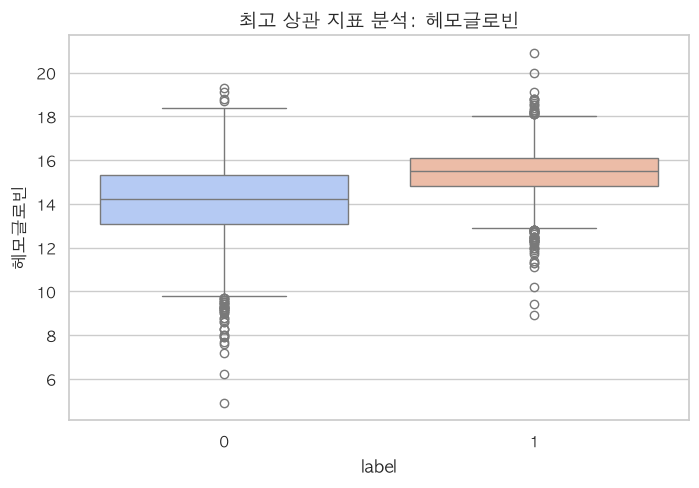

In [38]:
#최고 상관 지표 분석
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y=strong_corr.index[0], data=health_data, palette='coolwarm')
plt.title(f'최고 상관 지표 분석: {strong_corr.index[0]}', fontsize=14)
plt.savefig('../images/02_hypothesis/14_최고_상관_지표.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 결론 도출
어떤 요인이 흡연 여부와 관련성이 높은지 인사이트 제시

예시)
- 흡연자는 비흡연자에 비해 평균 혈압과 중성지방 수치가 유의하게 높았습니다.(p<0.05)
- 반면, BMI는 유의한 차이가 없었습니다. (p>0.05)
- 따라서 흡연은 대사 관련 지표(혈압, 중성지방)에 더 큰 영향을 미치는 것으로 해석할 수 있습니다.

### 어떤 요인이 흡연 여부와 관련성이 높을까요 ? 그 이유는?
본 분석 결과, 흡연 여부는 헤모글로빈과 동맥경화 지수를 중심으로 가장 강한 연관성을 보였으며,
구강 염증(충치)을 매개로 대사 및 간 기능 지표에도 영향을 미치는 복합적인 건강 위험 요인임을 확인하였다.
흡연은 단순한 생활습관을 넘어 구강·대사·간 건강 전반에 연쇄적 영향을 미친다.